In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.chdir("/scratch/go76fil/Programs/Python/Paper_Topic_Modelling")
os.getcwd()

'/scratch/go76fil/Programs/Python/Paper_Topic_Modelling'

In [4]:
import pickle
with open('./output/store/pdf_files.pkl', 'rb') as f:
    pdf_files, year = pickle.load(f)
with open('./output/store/preprocessed_pdf_files.pkl', 'rb') as f:
    preprocessed_pdf_files, _ = pickle.load(f)
with open('./output/store/light_preprocessed_pdf_files.pkl', 'rb') as f:
    light_preprocessed_pdf_files, _ = pickle.load(f)

In [5]:
print(len(pdf_files))
print(len(preprocessed_pdf_files))
print(len(light_preprocessed_pdf_files))

555
555
555


In [24]:
from src.optimisation import MTObjective, CLObjective, OCDObjective, CDOObjective
from src.optimisation import basic_space  
from numpy.random import default_rng
seed = 42
objective = CDOObjective(
    docs=light_preprocessed_pdf_files,
    analyzer="word",
    seed=seed,
    gpu=True,
    top_n=50
)
space = basic_space()

In [21]:
from hyperopt import fmin, tpe, Trials, space_eval

trials = Trials()
best = fmin(
    fn=objective,        
    space=space,           
    algo=tpe.suggest,      
    max_evals=300,          
    trials=trials,
    rstate=default_rng(seed)
)
best_hyperparams = space_eval(space, best)

print("Best hyperparameters:")
print(best_hyperparams)

Loss and Details                                                                                              
-1.1333162827326042                                                                                           
{'coherence': 0.3904946167677401, 'diversity': 1.0, 'outlier_ratio': 0.5351351351351351, 'outlier_penalty': 0.1400299490048137}
Error with params {'embedding_model': 'allenai/scibert_scivocab_uncased', 'hdbscan_model': {'min_cluster_size': 29, 'min_samples': 17}, 'umap_model': {'metric': 'manhattan', 'min_dist': 0.059936189081400526, 'n_components': 10, 'n_neighbors': 16}}: max_df corresponds to < documents than min_df
Loss and Details                                                                                              
-1.2136307273547966                                                                                           
{'coherence': 0.4188618089698829, 'diversity': 1.0, 'outlier_ratio': 0.418018018018018, 'outlier_penalty': 0.07957253892412144}
Loss 

In [22]:
with open('./output/store/CDO_300_v2.pkl', 'wb') as f:
    pickle.dump((trials,best_hyperparams), f)

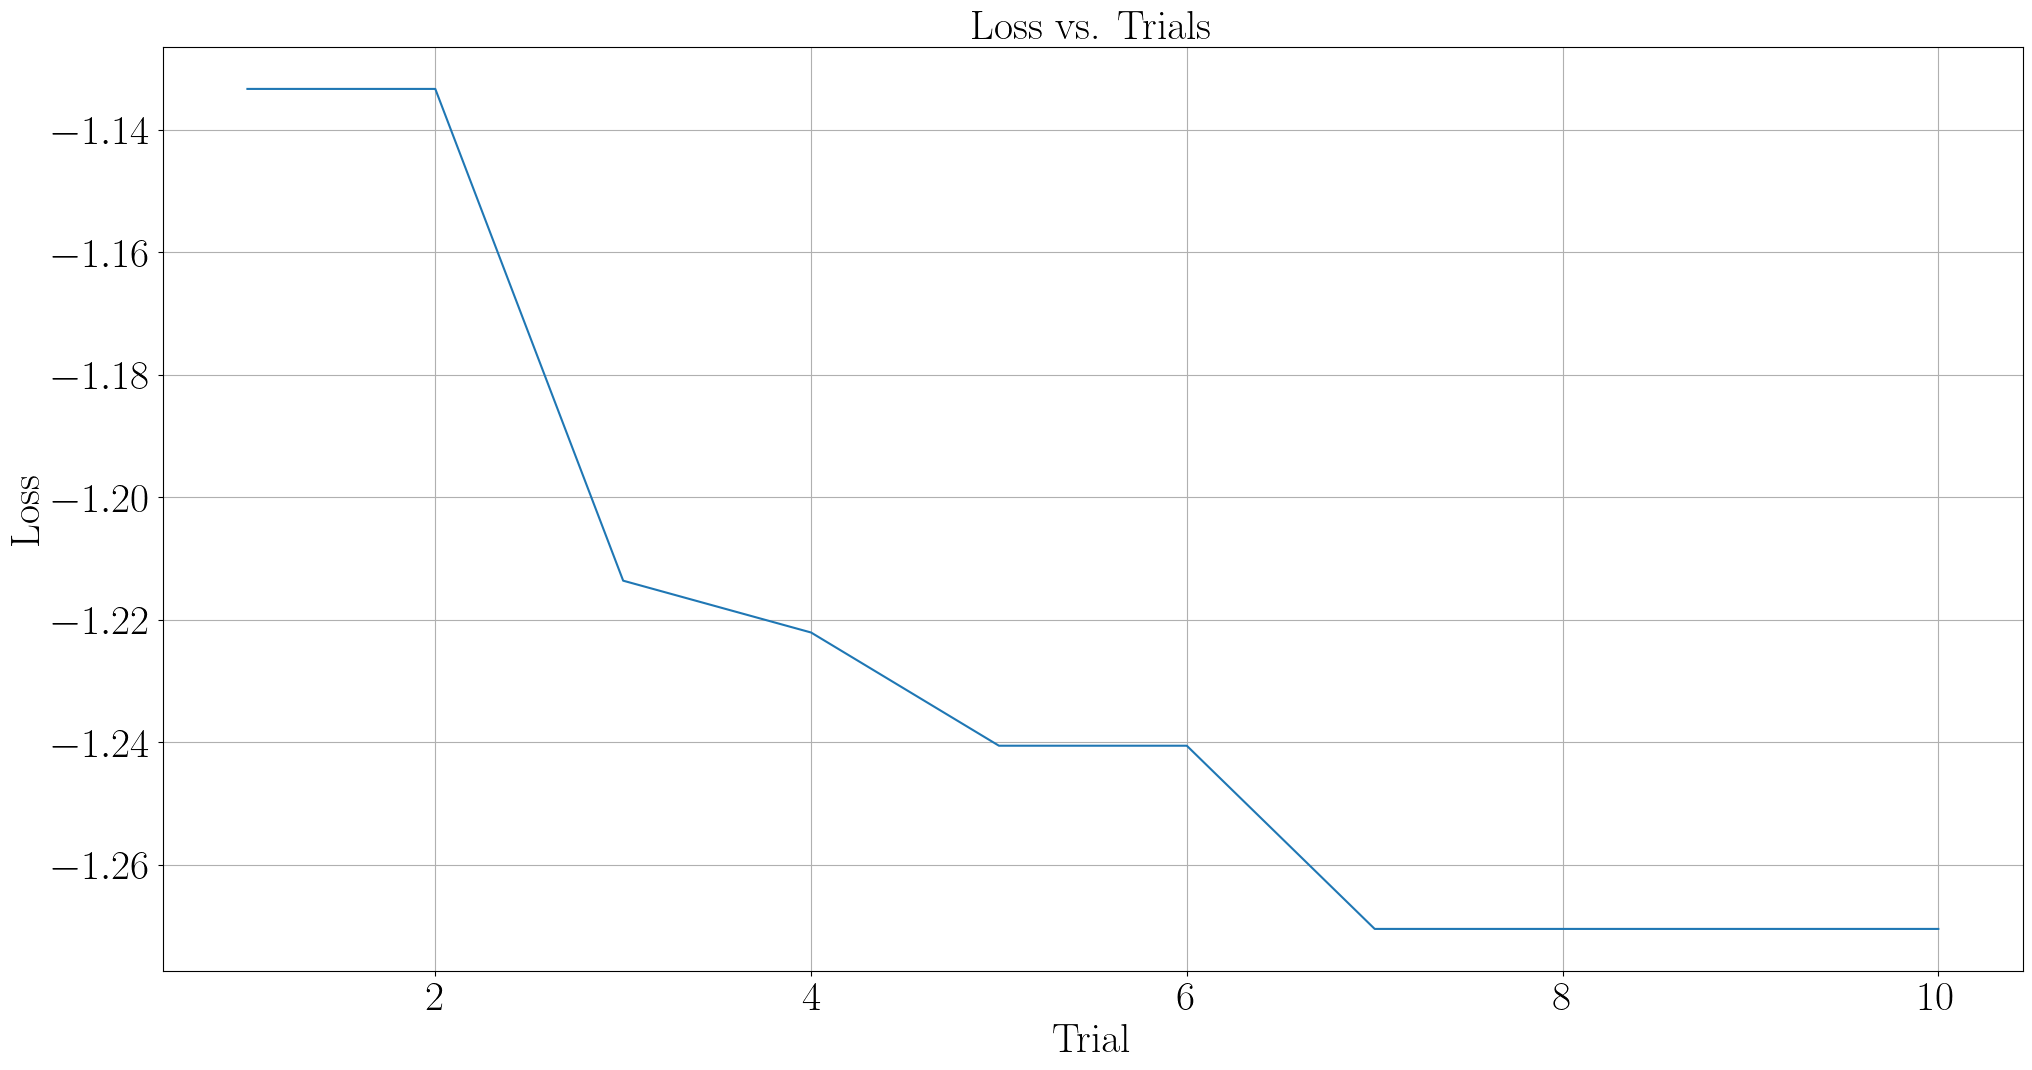

In [23]:
from src.optimisation import plot_best_loss
plot_best_loss(trials)